In [1]:
import pandas as pd
import numpy as np
import re
from scripts import mcmc
from scripts import stability_analysis
from scripts import fem_vis
from scripts import fem_solve

#import matplotlib
#matplotlib.use('QtAgg')
%matplotlib inline
import matplotlib.pyplot as plt

NUM = re.compile(r"[-+]?(?:\d+\.?\d*|\.\d+)(?:[eE][-+]?\d+)?")

In [ ]:
n = 10
df = pd.read_csv("results/08_13_2026_mcmc_results/fem_evals.csv")

params = df['Parameters']

print(params)

values = df['Value']
wid = df['Walker']
params_arr = []
values_arr = []
wid_arr = []

for i, param in enumerate(params):
    params_arr.append(mcmc._parse_params(param, n_params=7))
    values_arr.append(values.loc[i])
    wid_arr.append(wid.loc[i])

params_arr = np.asarray(params_arr)
values_arr = np.asarray(values_arr)
wid_arr = np.asarray(wid_arr)

best = np.argsort(values_arr)
tn_params = params_arr[best][:n]

refined = []
for i, params_mm in enumerate(tn_params):
    refined.append(mcmc.NM_opt(params_mm,500,save_path='./results/08_17_2026_NM_results/', csv_name=f'nm_evals_{i}.csv'))

print(refined)

0        [ 17.04266527,115.96094767,  8.55506169,  5.97...
1        [ 39.00404523,120.6579613 ,  4.99950343,  8.77...
2        [  3.18419527,117.41799453,  7.0308472 ,  4.86...
3        [30.2483466 ,91.13992859, 6.83837635,15.404033...
4        [33.39052594,97.30000367, 6.27306053, 3.980221...
                               ...                        
25005    [  7.87413238,130.06292142,  4.27333455,  8.51...
25006    [ 26.88091499,113.52046476,  5.87047507, 17.47...
25007    [  4.95355341,130.4554907 ,  8.4274445 , 17.23...
25008    [ 12.69366881,125.95467501,  4.74552023,  4.92...
25009    [ 28.8250536 ,128.52439642,  3.14340947, 10.24...
Name: Parameters, Length: 25010, dtype: str
[10:13:43] NM eval     1 (iter    0) |    7.5s | FOM=1.40318e+31 | feasible | best=1.40318e+31
[10:13:51] NM eval     2 (iter    0) |    7.5s | FOM=1.40787e+31 | feasible | best=1.40318e+31

[NM_opt] interrupted after 2 evaluations; ./08_17_2026_NM_results/nm_evals_0.csv holds everything so far.

[NM_opt] 

In [17]:
df = pd.read_csv("results/08_13_2026_mcmc_results/fem_evals.csv")

params = df['Parameters']

print(params)

values = df['Value']
wid = df['Walker']
params_arr = []
values_arr = []
wid_arr = []

for i, param in enumerate(params):
    params_arr.append(mcmc._parse_params(param, n_params=7))
    values_arr.append(values.loc[i])
    wid_arr.append(wid.loc[i])

params_arr = np.asarray(params_arr)
values_arr = np.asarray(values_arr)
wid_arr = np.asarray(wid_arr)

# ignore the 1e+33 values
ignore_args = np.where(values_arr!=1e+33)
values_arr = values_arr[ignore_args]
wid_arr = wid_arr[ignore_args]
params_arr = params_arr[ignore_args]

#print(values_arr)
#print(params_arr)

print(np.mean(np.log(values_arr)))
print(np.std(np.log(values_arr)))

0        [ 17.04266527,115.96094767,  8.55506169,  5.97...
1        [ 39.00404523,120.6579613 ,  4.99950343,  8.77...
2        [  3.18419527,117.41799453,  7.0308472 ,  4.86...
3        [30.2483466 ,91.13992859, 6.83837635,15.404033...
4        [33.39052594,97.30000367, 6.27306053, 3.980221...
                               ...                        
25005    [  7.87413238,130.06292142,  4.27333455,  8.51...
25006    [ 26.88091499,113.52046476,  5.87047507, 17.47...
25007    [  4.95355341,130.4554907 ,  8.4274445 , 17.23...
25008    [ 12.69366881,125.95467501,  4.74552023,  4.92...
25009    [ 28.8250536 ,128.52439642,  3.14340947, 10.24...
Name: Parameters, Length: 25010, dtype: str
72.1567437916357
0.23866271717311927


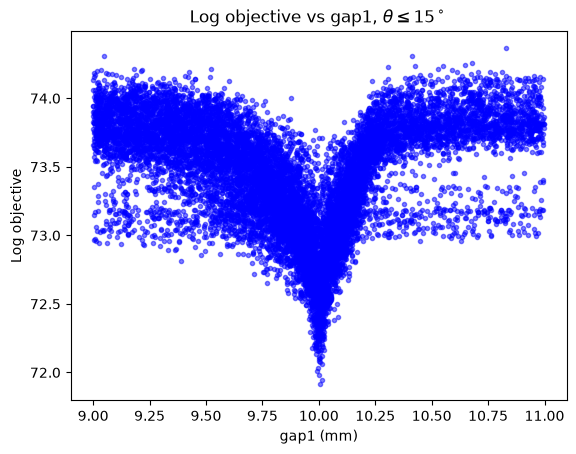

In [19]:
# sort by where theta is
small_theta_args = np.where(theta_vals<=15)
large_theta_args = np.where(theta_vals>15)
gap_1_small_theta = gap1_vals[small_theta_args]
gap_1_large_theta = gap1_vals[large_theta_args]
small_theta_values = values_arr[small_theta_args]
large_theta_values = values_arr[large_theta_args]

fig,ax=plt.subplots()
ax.scatter(gap_1_small_theta, np.log(small_theta_values), marker='.', c='b', alpha=0.5)
#ax.scatter(gap_1_large_theta, np.log(large_theta_values), marker='.', c='b', alpha=0.5)
ax.set_ylabel('Log objective')
ax.set_xlabel('gap1 (mm)')
ax.set_title('Log objective vs gap1, $\\theta\\leq15^\\circ$')
plt.show()

IndexError: index 23600 is out of bounds for axis 0 with size 23597

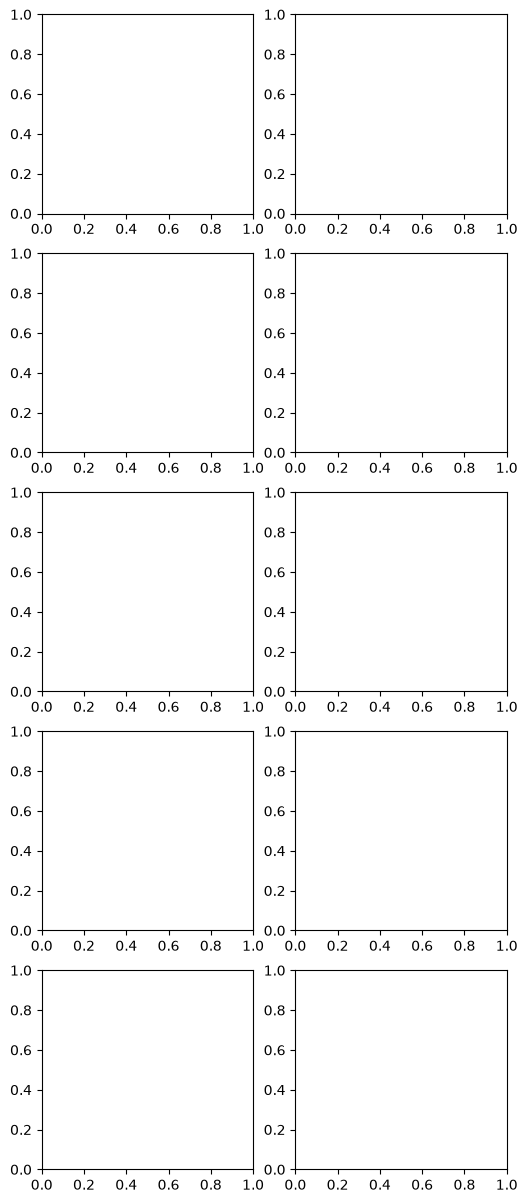

In [ ]:
fig,ax=plt.subplots(5, 2, figsize=(6,15))
ax_flat = ax.flatten()
for walker_id in range(10):
    walker_id_args = np.where(wid_arr==walker_id)
    #gap1_vals_wid = gap1_vals[walker_id_args]
    values_wid = values_arr[walker_id_args]
    print(f'best result for walker id {walker_id}: {np.min(values_wid)}')
    #ax_flat[walker_id].scatter(gap1_vals_wid, np.log(values_wid), marker='.', c='b')
plt.tight_layout()
plt.show()

In [18]:
best = np.argsort(values_arr)
t10_params = params_arr[best][:10]
print(values_arr[best][:10])
print(t10_params)

best_params = params_arr[best][0]
print(best_params)
#print(mcmc.fom(best_params, verbose=True))

[1.40322454e+31 1.43446165e+31 1.43699462e+31 1.44160387e+31
 1.44284948e+31 1.44299183e+31 1.44370317e+31 1.44534859e+31
 1.44668579e+31 1.45238546e+31]
[[7.83871556e+00 1.26157650e+02 9.19378470e+00 1.75440332e+01
  1.85117677e+01 1.26545044e+02 1.25794783e+02]
 [1.04131760e+01 1.27604674e+02 9.71941801e+00 1.49941992e+01
  1.61405783e+01 1.23185357e+02 1.23329815e+02]
 [1.65540628e+00 1.27173754e+02 5.09884073e+00 1.10134959e+01
  1.24167942e+01 1.20000917e+02 1.21034979e+02]
 [6.92547548e+00 1.28346095e+02 9.92317387e+00 1.58849644e+01
  1.55633500e+01 1.24140786e+02 1.23049101e+02]
 [1.21587259e+01 1.29350555e+02 3.90861476e+00 8.41316564e+00
  8.78437937e+00 1.23984885e+02 1.23945576e+02]
 [9.03969037e+00 1.27776773e+02 9.66440008e+00 1.40262216e+01
  1.49625701e+01 1.23065562e+02 1.21762701e+02]
 [2.82339541e-02 1.27102123e+02 9.86038847e+00 1.42909249e+01
  1.55974258e+01 1.25284726e+02 1.24481922e+02]
 [6.68087198e+00 1.26810207e+02 8.88535606e+00 1.68709783e+01
  1.71117168e+

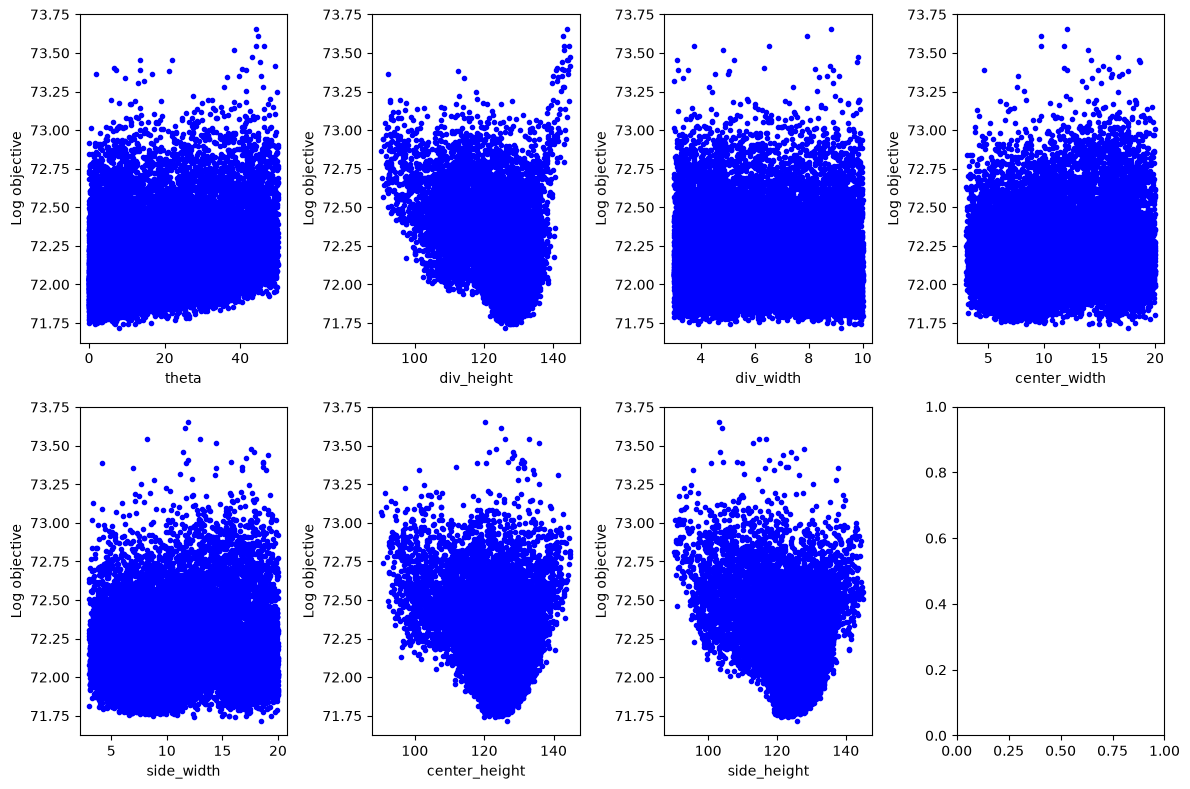

In [19]:
param_names = ['theta', 'div_height', 'div_width', 'center_width', 'side_width', 'center_height', 'side_height']
num_params = len(param_names)
fig, ax = plt.subplots(2,4, figsize=(12,8))
ax_flat = ax.flatten()

for i, name in enumerate(param_names):
    ax_flat[i].scatter(params_arr[:,i], np.log(values_arr), c='b', marker='.')
    ax_flat[i].set_xlabel(name)
    ax_flat[i].set_ylabel("Log objective")

plt.tight_layout()
plt.show()

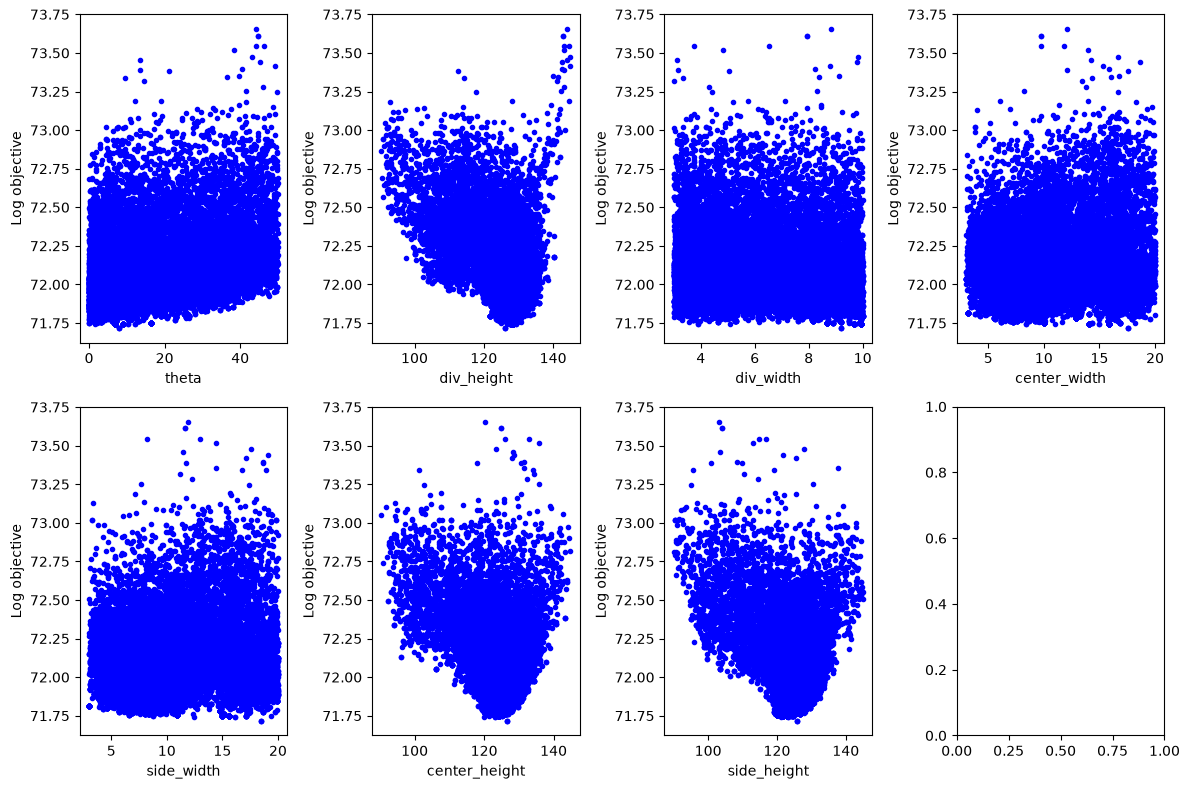

In [21]:
df_all = pd.read_csv('results/08_13_2026_mcmc_results/all_params_all_values.csv')
params_all = df_all['Parameters']
values_all = df_all['Value']
wid_all = df_all['Walker']
params_arr_all = []
values_arr_all = []
wid_arr_all = []

for i, param in enumerate(params_all):
    params_arr_all.append(mcmc._parse_params(param, n_params=7))
    values_arr_all.append(values_all.loc[i])
    wid_arr_all.append(wid_all.loc[i])

params_arr_all = np.asarray(params_arr_all)
values_arr_all = np.asarray(values_arr_all)
wid_arr_all = np.asarray(wid_arr_all)

ignore_args_all = np.where(values_arr_all!=1e+33)
values_arr_all = values_arr_all[ignore_args_all]
wid_arr_all = wid_arr_all[ignore_args_all]
params_arr_all = params_arr_all[ignore_args_all]

param_names = ['theta', 'div_height', 'div_width', 'center_width', 'side_width', 'center_height', 'side_height']
num_params = len(param_names)
fig, ax = plt.subplots(2, 4, figsize=(12,8))
ax_flat = ax.flatten()

for i, name in enumerate(param_names):
    ax_flat[i].scatter(params_arr_all[:,i], np.log(values_arr_all), c='b', marker='.')
    ax_flat[i].set_xlabel(name)
    ax_flat[i].set_ylabel("Log objective")

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Log objective')

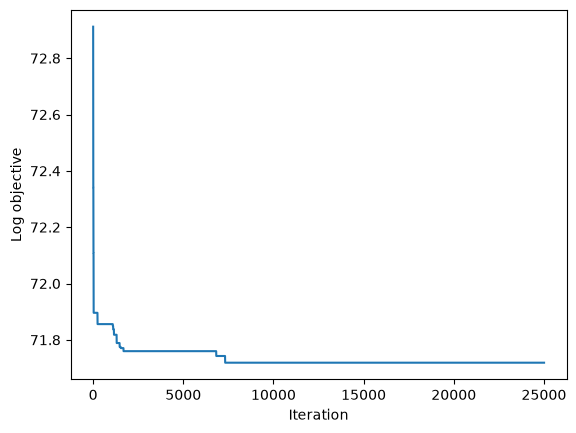

In [22]:
# best so far plot

best_so_far = np.minimum.accumulate(values_arr_all)
fig, ax = plt.subplots()
ax.plot(np.linspace(1, len(best_so_far), len(best_so_far)), np.log(best_so_far))
ax.set_xlabel('Iteration')
ax.set_ylabel('Log objective')

2500


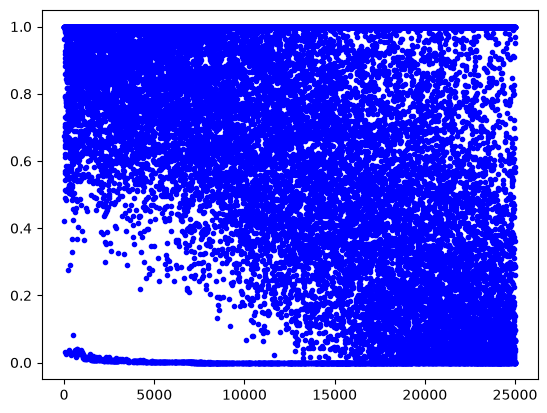

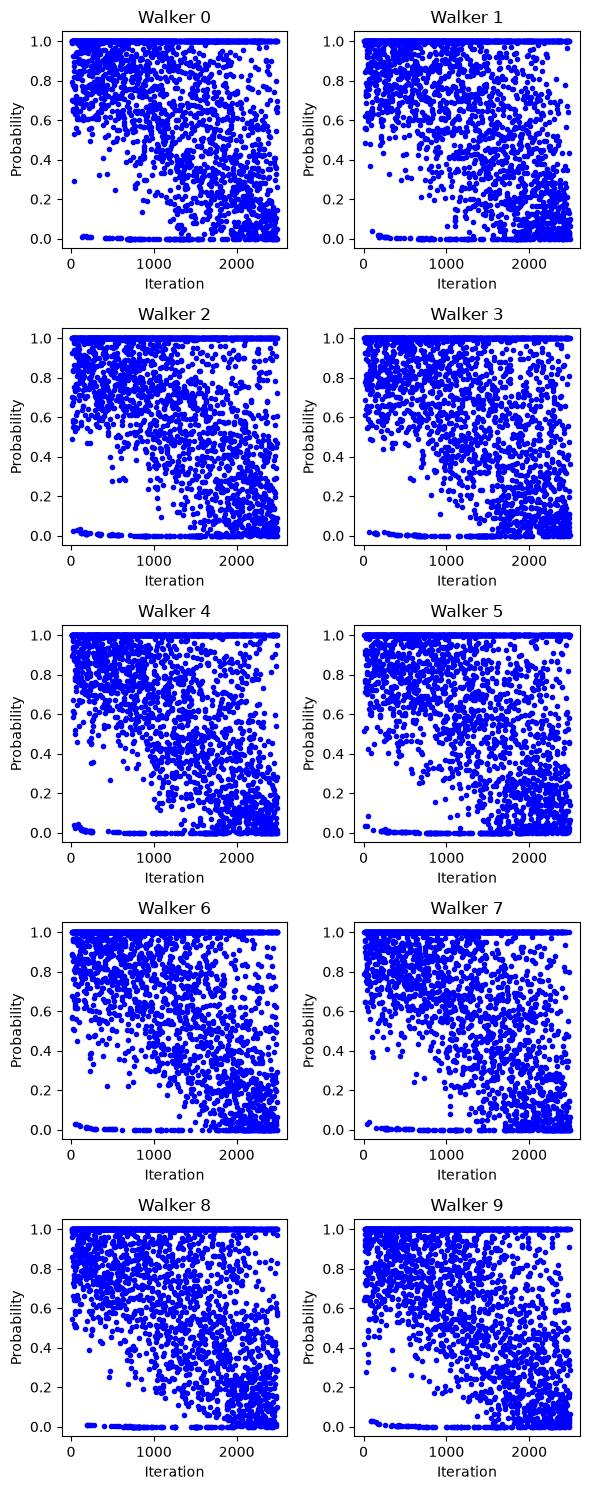

In [23]:
probs = df["AcceptProb"]
fig, ax = plt.subplots()
ax.scatter(probs[-np.isnan(df["AcceptProb"])].index, probs[-np.isnan(df["AcceptProb"])], marker='.', c='b')

probs = np.asarray(probs)
wid_arr = np.asarray(wid)

fig,ax=plt.subplots(5, 2, figsize=(6,15))
ax_flat = ax.flatten()
for walker_id in range(10):
    walker_id_args = np.where(wid_arr==walker_id)
    probs_wid = probs[walker_id_args]
    probs_wid = probs_wid[~np.isnan(probs_wid)]
    inds = np.linspace(10, len(probs_wid)-10, len(probs_wid))
    #print(len(inds))
    #print(f'best result for walker id {walker_id}: {np.min(values_wid)}')
    ax_flat[walker_id].scatter(inds, probs_wid, marker='.', c='b')
    ax_flat[walker_id].set_title(f'Walker {walker_id}')
    ax_flat[walker_id].set_xlabel('Iteration')
    ax_flat[walker_id].set_ylabel('Probability')

print(len(inds))
plt.tight_layout()
plt.show()


range for theta: [np.float64(0.0282339541), np.float64(16.30578022)]
range for div_height: [np.float64(125.07576029), np.float64(129.35055532)]
range for div_width: [np.float64(3.90861476), np.float64(9.92317387)]
range for center_width: [np.float64(8.41316564), np.float64(18.21328737)]
range for side_width: [np.float64(8.78437937), np.float64(19.3905675)]
range for center_height: [np.float64(120.00091749), np.float64(126.54504376)]
range for side_height: [np.float64(120.05751578), np.float64(125.79478309)]


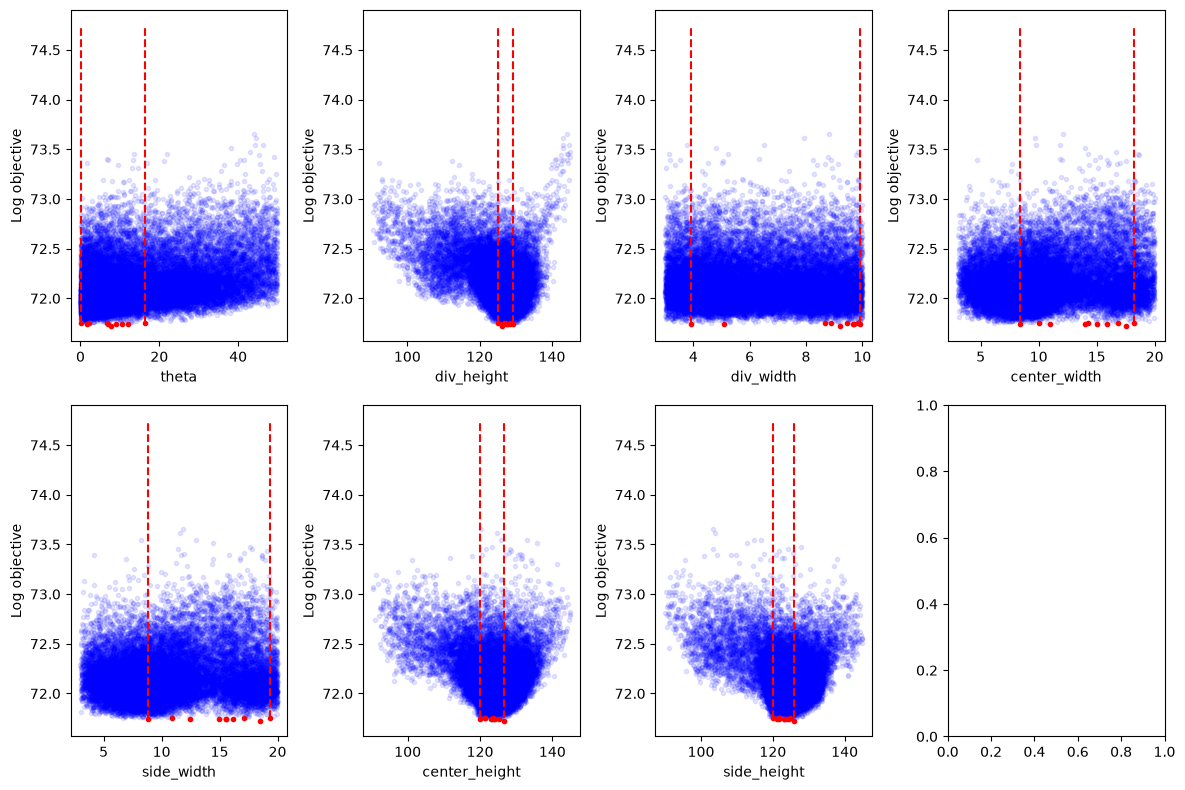

In [ ]:
fig, ax = plt.subplots(2, 4, figsize=(12,8))
ax_flat = ax.flatten()

n = 10
tn_params = params_arr[best][:n]

for i, name in enumerate(param_names):
    #print(f'optimal {name}s: {t10_params[:,i]}\n')
    ax_flat[i].scatter(params_arr[:,i], np.log(values_arr), c='b', marker='.', alpha=0.1)
    ax_flat[i].set_xlabel(name)
    ax_flat[i].set_ylabel("Log objective")
    ax_flat[i].vlines([np.min(tn_params[:,i]), np.max(tn_params[:,i])], 71.75, 74.75, colors='r', ls='--')
    print(f'range for {name}: {[np.min(tn_params[:,i]), np.max(tn_params[:,i])]}')
    ax_flat[i].scatter(tn_params[:,i], np.log(values_arr[best][:n]), c='r', marker='.')

plt.tight_layout()
plt.show()

In [35]:
print(mcmc.fom([43.08239729, 128.44919526, 5.33452249, 9.99969355, 6.26901851, 6.59042247, 125.13866136, 123.95102582], verbose=True))
print()
print(mcmc.fom([0, 128.44919526, 5.33452249, 10, 6.26901851, 6.59042247, 125.13866136, 123.95102582], verbose=True))


  x= -0.00 y=  0.00  guess= 15.000  f= 15.008 GHz  C=0.5124  Q=    7618  loc=0.451
  x= -0.58 y=  0.55  guess= 14.173  f= 14.206 GHz  C=0.2609  Q=    7695  loc=0.178
  x= -1.17 y=  1.09  guess= 13.433  f= 13.473 GHz  C=0.2611  Q=    7929  loc=0.173
  x= -1.75 y=  1.64  guess= 12.766  f= 12.819 GHz  C=0.2532  Q=    8328  loc=0.189
  x= -2.33 y=  2.18  guess= 12.162  f= 12.221 GHz  C=0.2080  Q=    8705  loc=0.163
  x= -2.92 y=  2.73  guess= 11.613  f= 11.646 GHz  C=0.2937  Q=    8765  loc=0.260
  x= -3.50 y=  3.27  guess= 11.111  f= 11.169 GHz  C=0.2068  Q=    9208  loc=0.172
  x= -4.08 y=  3.82  guess= 10.651  f= 10.686 GHz  C=0.2231  Q=    9239  loc=0.199
  x= -4.67 y=  4.36  guess= 10.227  f= 10.279 GHz  C=0.2249  Q=    9212  loc=0.142
  x= -5.25 y=  4.91  guess=  9.836  f=  9.892 GHz  C=0.2314  Q=    9487  loc=0.166
  x= -5.83 y=  5.46  guess=  9.474  f=  9.541 GHz  C=0.2089  Q=    9597  loc=0.148
  x= -6.42 y=  6.00  guess=  9.137  f=  9.216 GHz  C=0.1799  Q=    9825  loc=0.160
  x=

In [10]:
# stability analysis

nominal_result, samples, summary=stability_analysis.check_stability(best_params, num_samples=3, theta_err=0.1, length_err=0.03)
print(summary)
#print(nominal_result, samples, summary)

[stability] nominal gaps (mm): [10. 10. 10. 10. 10. 10.]
[stability] tolerances: {'width': 0.03, 'height': 0.03, 'position': 0.03, 'cavity_w': 0.03, 'cavity_h': 0.03, 'angle_deg': 0.1, 'correlated_parts': False}
[stability] 3 samples x 16 tuning steps
[stability] nominal: angle=0.16899349, cav_w=102.96938212, cav_h=160.0, ctr_w=9.41222406, ctr_h=123.2129638, ctr_x=0.0, ctr_y=0.0, divL_w=5.83007533, divL_h=128.74669068, divL_x=-17.621149695, divL_y=0.0, divR_w=5.83007533, divR_h=128.74669068, divR_x=17.621149695, divR_y=0.0, sideL_w=10.9485037, sideL_h=124.9380107, sideL_x=-36.01043921, sideL_y=0.0, sideR_w=10.9485037, sideR_h=124.9380107, sideR_x=36.01043921, sideR_y=0.0
[stability] nominal: FOM=1.40416e+31  meanC=0.2481  meanQ=9180  band 8.100-14.981 GHz (12.0s)
  [1/3] angle=0.14695428859043763, cav_w=102.99453295710423, cav_h=160.00558181600545, ctr_w=9.421930211490004, ctr_h=123.26313244521755, ctr_x=0.06478020253073002, ctr_y=0.018376004740210814, divL_w=5.805879098311237, divL_h=

KeyboardInterrupt: 

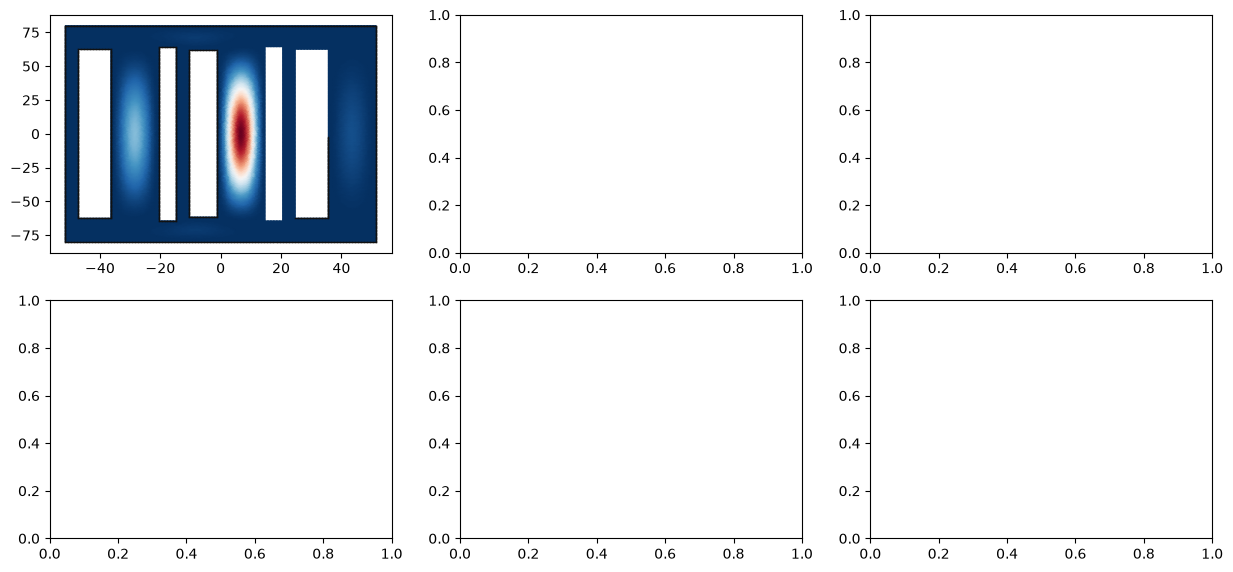

In [78]:
#params_m = mcmc._params_to_m(best_params)
#spec = fem_vis.toaster_spec(params_m, mesh_size=0.001, mesh_uniform=True)
mcmc.sim_sweep([0.16899349, 128.74669068, 5.83007533, 10., 9.41222406,  10.9485037, 123.2129638, 124.9380107], plot_all=True)

#fem_vis.plot_best_modes_magnitude_square(best_params, save='results/08_11_2026_stability_analysis_nominal.png')

In [41]:
for i, params_mm in enumerate(tn_params): 
    #best_params_mm = np.asarray([7.83871556e+00, 1.26157650e+02, 9.19378470e+00, 1.75440332e+01, 1.85117677e+01, 1.26545044e+02, 1.25794783e+02])
    params_m = mcmc._params_to_m(params_mm)
    spec = fem_vis.toaster_spec(params_m)
    if i == 0:
        fem_vis.plot_spec(spec, save=f'results/08_13_2026_mcmc_results/plots/toaster_geometry_center.png')
    specs,results = fem_solve.run_sweep(
        lambda dx, dy, i: mcmc.make_spec(params_mm, toast_dx=dx, toast_dy=dy, tag=f"x={dx*1e3:.2f}mm"),
        mcmc.tuning_positions(params_mm),        # yields (dx, dy, f_guess) per step
        n_modes=6,
        n_workers=None,            # every core
        timeout=600,               # bad geometry fails instead of stalling
        plot_all=True,          # needed for plot_best_modes
    )
    entries = [(s, r, f"x={x*1e3:.2f} mm")
                for (x, _y, _f), s, r in zip(mcmc.tuning_positions(params_mm), specs, results)
                if r["ok"]]
    fem_vis.plot_best_modes_magnitude_square(entries, save=f'results/08_13_2026_mcmc_results/plots/toaster_tuning_modes_{i+1}.png')

[batch] 1/16 tag='x=-0.00mm' f0=15.0140 GHz
[batch] 2/16 tag='x=-1.17mm' f0=13.4592 GHz
[batch] 3/16 tag='x=-1.75mm' f0=12.7939 GHz
[batch] 4/16 tag='x=-2.33mm' f0=12.0817 GHz
[batch] 5/16 tag='x=-0.58mm' f0=14.1893 GHz
[batch] 6/16 tag='x=-5.25mm' f0=9.7487 GHz
[batch] 7/16 tag='x=-2.92mm' f0=11.5027 GHz
[batch] 8/16 tag='x=-3.50mm' f0=11.1470 GHz
[batch] 9/16 tag='x=-4.08mm' f0=10.6136 GHz
[batch] 10/16 tag='x=-6.42mm' f0=8.8644 GHz
[batch] 11/16 tag='x=-8.75mm' f0=7.7335 GHz
[batch] 12/16 tag='x=-4.67mm' f0=10.1212 GHz
[batch] 13/16 tag='x=-8.17mm' f0=7.9741 GHz
[batch] 14/16 tag='x=-5.83mm' f0=9.3196 GHz
[batch] 15/16 tag='x=-7.00mm' f0=8.6901 GHz
[batch] 16/16 tag='x=-7.58mm' f0=8.4860 GHz
[batch] 1/16 tag='x=-2.33mm' f0=12.1373 GHz
[batch] 2/16 tag='x=-0.00mm' f0=15.0197 GHz
[batch] 3/16 tag='x=-2.92mm' f0=11.4183 GHz
[batch] 4/16 tag='x=-1.17mm' f0=13.4597 GHz
[batch] 5/16 tag='x=-5.83mm' f0=9.2274 GHz
[batch] 6/16 tag='x=-6.42mm' f0=9.1547 GHz
[batch] 7/16 tag='x=-8.75mm' f0=7.